# EDU Pre-Vibe vs Post-Vibe: segmented-demodulation comparison

A concise re-statement of the Pre/Post-vibration comparison of the EDU R1 resonator
using **exclusively the segmented-demodulation estimator**
(`ringdownanalysis.demod.SegmentedDemodEstimator`) and its companion nonlinear-damping
model (`ringdownanalysis.nonlinear.fit_nonlinear_damping`). No coherent estimator
(`Q_profile`, `Q_nls`, `Q_dft`) or envelope diagnostic appears anywhere in this notebook.

The full evidence chain — why the coherent estimators fail on these records and how the
demod estimator was validated — lives in
`notebooks/20260818_EDU_PreVibe_vs_PostVibe_RingDown.ipynb` (historical record) and
`notebooks/20260819_EDU_SegmentedDemod_Estimator_Demo.ipynb` (current-library demo).
The whole-decay numbers below are pinned by `tests/test_real_data_regression.py`.

**Data** (Moku:Pro Phasemeter exports, ≈ 149.01 Hz; not tracked in the repo):

| Epoch | File | Ring-down channel |
|---|---|---|
| Pre-Vibe (2026-03-21) | `data/ODIN/20260321_EDU_R1.csv.zip` | ch1 (PD1M) |
| Post-Vibe (2026-03-25) | `data/ODIN/20260325_EDU_R1.csv.zip` | ch2 (PD1R) |

**How to run:** activate the venv (`source .venv/bin/activate`) and run all cells from
`notebooks/`. Requires `mokutools`. Runtime ≈ 2 minutes; results are deterministic.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mokutools.phasemeter import MokuPhasemeterObject

from ringdownanalysis.demod import SegmentedDemodEstimator
from ringdownanalysis.nonlinear import fit_nonlinear_damping

%matplotlib inline

DATA_DIR = Path("..").resolve() / "data" / "ODIN"
FILES = {
    "Pre-Vibe": (DATA_DIR / "20260321_EDU_R1.csv.zip", 1),
    "Post-Vibe": (DATA_DIR / "20260325_EDU_R1.csv.zip", 2),
}
# Approximate R1 resonance. Passed as f_init because the raw records carry large
# baseline wander; a full-record DFT without a band hint can lock onto the wander.
F_NOMINAL = 7.6699
COLORS = {"Pre-Vibe": "C0", "Post-Vibe": "C1"}

records = {}
for label, (path, ch) in FILES.items():
    assert path.exists(), f"Missing data file: {path}"
    pm = MokuPhasemeterObject(filename=str(path), start_time=0, duration=3600 * 24)
    t = pm.df["time"].values
    records[label] = (t - t[0], pm.df[f"{ch}_cycles"].values, float(pm.fs))
    print(f"{label}: fs = {pm.fs:.3f} Hz, duration = {t[-1] - t[0]:.0f} s, channel {ch}")

Pre-Vibe: fs = 149.012 Hz, duration = 28350 s, channel 1


Post-Vibe: fs = 149.012 Hz, duration = 62176 s, channel 2


## 1. Whole-decay estimates

One estimator call per record. The estimator segments the record (~96 segments),
demodulates each independently (immune to frequency drift), detects the ambient-driven
plateau, and fits the floor-corrected log amplitude over the contiguous decay region
with a robust Theil-Sen line. Amplitude bands are fixed to the same values for both
records so the banded Q values compare at matched amplitude.

In [2]:
AMP_BANDS = [(400.0, 700.0), (200.0, 400.0), (100.0, 200.0), (60.0, 100.0)]  # cycles

estimator = SegmentedDemodEstimator()
results = {
    label: estimator.estimate(t, y, fs, f_init=F_NOMINAL, amplitude_bands=AMP_BANDS)
    for label, (t, y, fs) in records.items()
}

summary = {}
for label, r in results.items():
    lo, hi = r.Q_ci95 if r.Q_ci95 is not None else (np.nan, np.nan)
    summary[label] = {
        "status": r.status,
        "Q (whole decay)": r.Q,
        "Q 95% CI low": lo,
        "Q 95% CI high": hi,
        "tau (s)": r.tau,
        "f mean (Hz)": r.f_mean,
        "plateau (cycles)": r.plateau_amplitude,
        "drift over decay (mHz)": r.drift_hz * 1e3,
        "coherence ratio |df|*tau": r.coherence_ratio,
        "decay segments": int(r.decay_mask.sum()),
    }
summary_df = pd.DataFrame(summary)
num = summary_df.drop(index=["status", "decay segments"]).astype(float)
summary_df.loc[num.index, "Change (%)"] = (
    100.0 * (num["Post-Vibe"] - num["Pre-Vibe"]) / num["Pre-Vibe"]
)
summary_df.round(4)

,Pre-Vibe,Post-Vibe,Change (%)
status,valid,valid,NaN
Q (whole decay),81319.594995,95425.851161,17.3467
Q 95% CI low,77050.791264,90849.330469,17.9084
Q 95% CI high,84878.141791,100908.199272,18.8860
tau (s),3374.706422,3960.561402,17.3602
f mean (Hz),7.670247,7.669365,-0.0115
plateau (cycles),16.28244,17.129049,5.1995
drift over decay (mHz),0.956941,0.195374,-79.5835
coherence ratio |df|*tau,3.229395,0.773791,-76.0391
decay segments,28,16,NaN


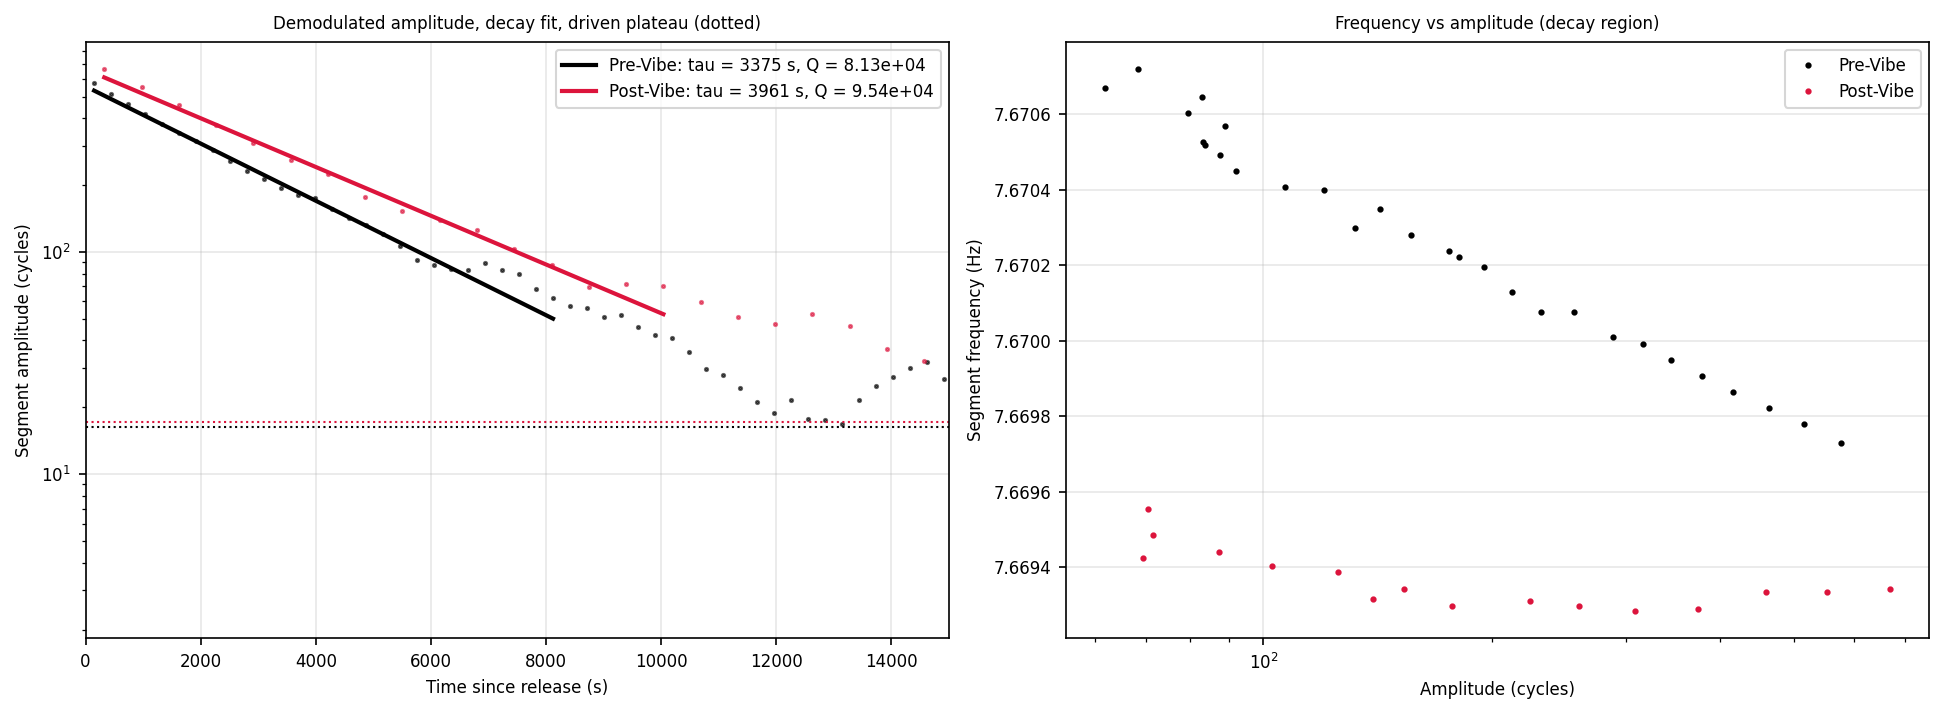

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for label, r in results.items():
    c = COLORS[label]
    m = r.decay_mask
    axes[0].semilogy(r.t_mid, r.amplitude, ".", ms=3, color=c, alpha=0.6)
    tt = r.t_mid[m]
    fit = np.exp(r.log_slope * tt + r.log_intercept)
    axes[0].semilogy(tt, fit, "-", lw=2, color=c,
                     label=f"{label}: tau = {r.tau:.0f} s, Q = {r.Q:.3g}")
    axes[0].axhline(r.plateau_amplitude, color=c, ls=":", lw=1)
    axes[1].semilogx(r.amplitude[m], r.f_seg[m], ".", ms=4, color=c, label=label)

axes[0].set_xlim(0, 15000)
axes[0].set_xlabel("Time since release (s)")
axes[0].set_ylabel("Segment amplitude (cycles)")
axes[0].set_title("Demodulated amplitude, decay fit, driven plateau (dotted)")
axes[1].set_xlabel("Amplitude (cycles)")
axes[1].set_ylabel("Segment frequency (Hz)")
axes[1].set_title("Frequency vs amplitude (decay region)")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

## 2. Q at matched amplitude

Both decays are genuinely non-exponential (local Q rises as the amplitude falls), so
the honest comparison is per amplitude band, not whole-decay average. The bands were
fixed to identical edges for both records in the estimator call above.

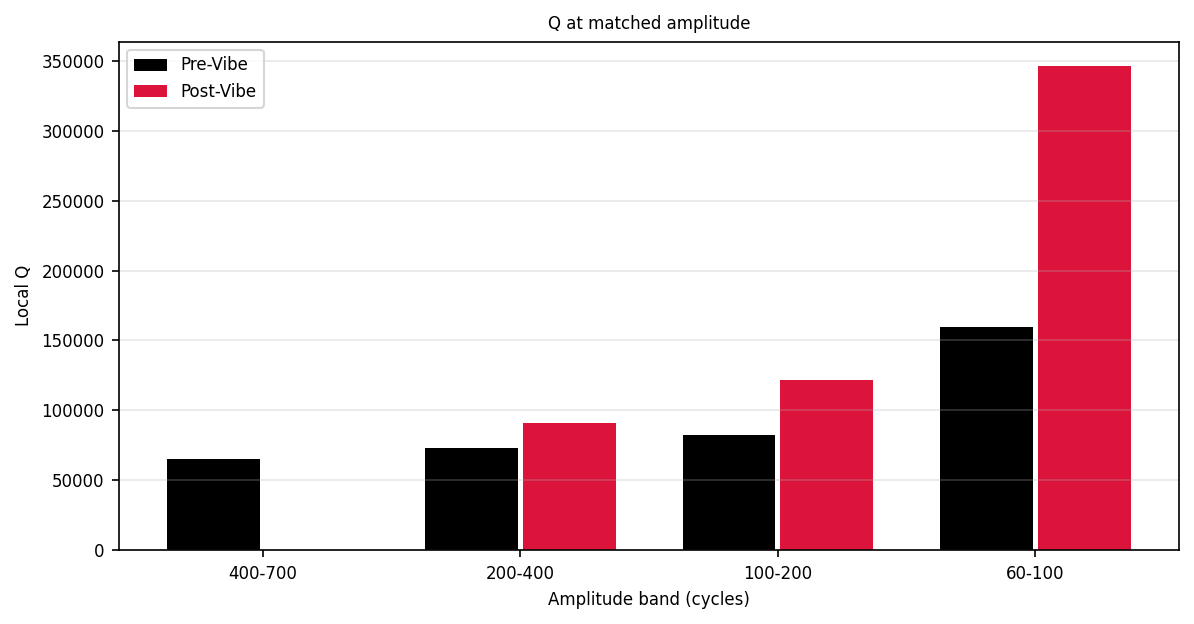

epoch,Post-Vibe,Pre-Vibe,Change (%),n_seg Pre/Post
band (cycles),,,,
400-700,NaN,65475.0,NaN,4/-
200-400,91238.0,73032.0,25.0,7/4
100-200,121985.0,82386.0,48.0,8/5
60-100,346547.0,159772.0,117.0,9/4


In [4]:
band_rows = []
for label, r in results.items():
    for band in r.q_vs_amplitude:
        band_rows.append(
            {"epoch": label,
             "band (cycles)": f"{band.amplitude_low:.0f}-{band.amplitude_high:.0f}",
             "A_mid": band.amplitude_mid, "n_seg": band.n_segments, "Q": band.Q}
        )
band_df = pd.DataFrame(band_rows)
order = [f"{lo:.0f}-{hi:.0f}" for lo, hi in AMP_BANDS]
band_pivot = band_df.pivot(index="band (cycles)", columns="epoch", values="Q").reindex(order)
band_pivot["Change (%)"] = (
    100.0 * (band_pivot["Post-Vibe"] - band_pivot["Pre-Vibe"]) / band_pivot["Pre-Vibe"]
)
n_seg = band_df.pivot(index="band (cycles)", columns="epoch", values="n_seg").reindex(order)
band_pivot["n_seg Pre/Post"] = [
    f"{'-' if np.isnan(a) else int(a)}/{'-' if np.isnan(b) else int(b)}"
    for a, b in zip(n_seg["Pre-Vibe"], n_seg["Post-Vibe"])
]

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(band_pivot))
for k, label in enumerate(["Pre-Vibe", "Post-Vibe"]):
    ax.bar(x + 0.38 * k, band_pivot[label], width=0.36, color=COLORS[label], label=label)
ax.set_xticks(x + 0.19)
ax.set_xticklabels(band_pivot.index)
ax.set_xlabel("Amplitude band (cycles)")
ax.set_ylabel("Local Q")
ax.set_title("Q at matched amplitude")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

band_pivot.round(0)

## 3. Frequency shift and amplitude pull

The per-segment frequencies from the same estimator calls give the resonance shift at
matched amplitude and the frequency-pull coefficient. The nonlinear-damping model then
summarizes each record with four physical parameters: zero-amplitude decay time
$\tau_0$ (and $Q_0 = \pi f \tau_0$), damping coefficient $\beta$ in
$1/\tau(A) = 1/\tau_0 + \beta A$, and the linear frequency pull $f(A) = f_0 + p\,A$.

In [5]:
# Frequency at matched amplitude: linear model f(ln A) over the decay region.
f_at = {}
for label, r in results.items():
    m = r.decay_mask
    coeff = np.polyfit(np.log(r.amplitude[m]), r.f_seg[m], 1)
    f_at[label] = lambda A, c=coeff: float(np.polyval(c, np.log(A)))
    print(f"{label}: f pull = {1e3 * coeff[0]:+.4f} mHz per amplitude e-fold "
          f"(demod result field: {1e3 * r.f_pull_per_efold:+.4f})")

for A_ref in (500.0, 60.0):
    df = f_at["Post-Vibe"](A_ref) - f_at["Pre-Vibe"](A_ref)
    print(f"Frequency shift @ A={A_ref:.0f} cycles: {1e3 * df:+.3f} mHz "
          f"({1e6 * df / F_NOMINAL:+.1f} ppm)")

# Nonlinear-damping model per record.
nl = {label: fit_nonlinear_damping(r) for label, r in results.items()}
nl_df = pd.DataFrame(
    {
        label: {
            "status": f.status,
            "tau0 (s)": f.tau0,
            "tau0 stderr (s)": f.tau0_stderr,
            "Q0 (zero-amplitude)": f.Q0,
            "beta (1e-7/(s*cycle))": 1e7 * f.beta if f.beta is not None else None,
            "tau @ A=500 (s)": float(f.tau_at(500.0)),
            "tau @ A=60 (s)": float(f.tau_at(60.0)),
            "f0 (Hz, zero-amplitude)": f.f_zero,
            "pull p (uHz/cycle)": 1e6 * f.f_pull if f.f_pull is not None else None,
        }
        for label, f in nl.items()
    }
)
nl_df

Pre-Vibe: f pull = -0.4307 mHz per amplitude e-fold (demod result field: -0.4307)
Post-Vibe: f pull = -0.0750 mHz per amplitude e-fold (demod result field: -0.0750)
Frequency shift @ A=500 cycles: -0.492 mHz (-64.1 ppm)
Frequency shift @ A=60 cycles: -1.246 mHz (-162.5 ppm)


,Pre-Vibe,Post-Vibe
status,valid,valid
tau0 (s),5041.122583,5370.377116
tau0 stderr (s),426.029492,483.516148
Q0 (zero-amplitude),121481.148337,129394.865021
beta (1e-7/(s*cycle)),4.299776,2.892423
tau @ A=500 (s),2419.214426,3022.720658
tau @ A=60 (s),4460.956489,4912.527579
"f0 (Hz, zero-amplitude)",7.670643,7.669418
pull p (uHz/cycle),-1.875492,-0.218968


## 4. Conclusions

1. **Q did not degrade across the vibration test.** The whole-decay average moved from
   ≈ 8.1×10⁴ to ≈ 9.5×10⁴ (+17 %, non-overlapping 95 % bootstrap CIs), and Q at matched
   amplitude is higher post-vibe in every comparable band (+25 % at 200–400 cycles,
   +48 % at 100–200). The +117 % in the 60–100 band rests on only 4 post-vibe segments
   and should be read as "not degraded", not as a precise gain. The zero-amplitude
   extrapolation of the nonlinear model agrees: Q₀ ≈ 1.21×10⁵ → 1.29×10⁵ (+7 %).
2. **The resonance frequency shifted down**, more at low amplitude: −0.49 mHz
   (−64 ppm) at A = 500 cycles, −1.25 mHz (−163 ppm) at A = 60 cycles.
3. **The amplitude–frequency pull weakened** by ≈ 6× (−0.43 → −0.075 mHz per amplitude
   e-fold; equivalently −1.9 → −0.22 µHz/cycle in the linear-in-A model).
4. **Both records keep the same pathologies** that motivated this estimator: an
   ambient-driven plateau of ≈ 16–17 cycles, amplitude-dependent damping
   (β > 0; local τ roughly doubles over the decay), and frequency drift whose coherence
   ratio $|\delta f|\cdot\tau$ (3.2 pre, 0.77 post) exceeds the coherent-estimator
   tolerance of 0.01 by 2 orders of magnitude — which is why coherent fits are gated
   out and this comparison uses the segmented-demodulation estimator alone.

These conclusions match the full investigation
(`notebooks/20260818_EDU_PreVibe_vs_PostVibe_RingDown.ipynb`, §4 and §6) with a fraction
of the code: two estimator calls and two nonlinear-model fits.